In [2]:
import numpy as np 
from sklearn.datasets import load_digits

In [3]:
X, y = load_digits(
    n_class=2,
    return_X_y=True,
)
y = y.reshape( -1,1)
print(X.shape, y.shape)

(360, 64) (360, 1)


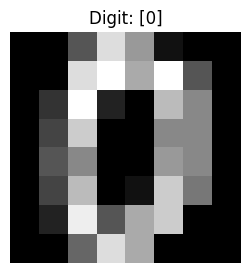

In [5]:
import matplotlib.pyplot as plt

idx = 0
plt.figure(figsize=(3,3))
plt.imshow(X[idx].reshape(8, 8), cmap='gray')
plt.title(f'Digit: {y[idx]}')
plt.axis('off')
plt.show()

In [9]:
from sklearn.preprocessing import normalize
X = normalize(X)

In [10]:
np.random.seed(0)
W1 = np.random.randn(X.shape[1], 2)
W2 = np.random.randn(2, 1)
y_pred = X @ W1 @ W2
R = y-y_pred # residual
error = np.mean ( R**2 ) # error
print(f'Mean squared error: {error}')

Mean squared error: 0.3250534774701159


(360, 2)


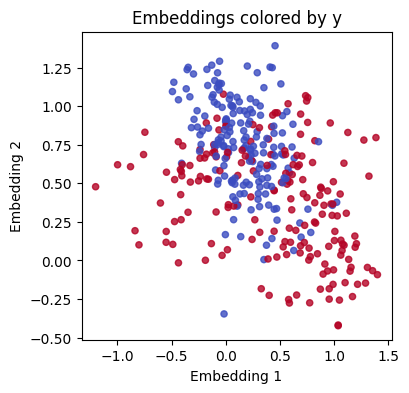

In [11]:
embeddings = X @ W1
print(embeddings.shape)

plt.figure(figsize=(4,4))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c=y.ravel(), cmap='coolwarm', s=20, alpha=0.8)
plt.xlabel('Embedding 1')
plt.ylabel('Embedding 2')
plt.title('Embeddings colored by y')
plt.show()

In [12]:

# Learning rate
alpha = 1e-1
n_items = X.shape[0]
scale = -2/n_items

all_losses = []
for epoch in range(500):
    # Forward pass
    y_pred = X @ W1 @ W2
    
    # Resiual
    R = y - y_pred

    # Error (Mean Squared Error)
    error = np.mean(R**2)
    all_losses.append(error)
    
    # Gradients (d(error)/d(parameters))
    grad_W2 = scale * W1.T @ X.T @ R
    grad_W1 = scale * X.T @ R @ W2.T
    
    # Update weights (step!)
    W1 -= alpha * grad_W1
    W2 -= alpha * grad_W2
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, MSE: {error:.4f}")

Epoch 0, MSE: 0.3251
Epoch 10, MSE: 0.2569
Epoch 20, MSE: 0.2131
Epoch 30, MSE: 0.1807
Epoch 40, MSE: 0.1557
Epoch 50, MSE: 0.1359
Epoch 60, MSE: 0.1199
Epoch 70, MSE: 0.1069
Epoch 80, MSE: 0.0961
Epoch 90, MSE: 0.0872
Epoch 100, MSE: 0.0798
Epoch 110, MSE: 0.0735
Epoch 120, MSE: 0.0683
Epoch 130, MSE: 0.0639
Epoch 140, MSE: 0.0601
Epoch 150, MSE: 0.0568
Epoch 160, MSE: 0.0540
Epoch 170, MSE: 0.0516
Epoch 180, MSE: 0.0495
Epoch 190, MSE: 0.0477
Epoch 200, MSE: 0.0460
Epoch 210, MSE: 0.0445
Epoch 220, MSE: 0.0432
Epoch 230, MSE: 0.0420
Epoch 240, MSE: 0.0409
Epoch 250, MSE: 0.0399
Epoch 260, MSE: 0.0390
Epoch 270, MSE: 0.0382
Epoch 280, MSE: 0.0374
Epoch 290, MSE: 0.0367
Epoch 300, MSE: 0.0360
Epoch 310, MSE: 0.0354
Epoch 320, MSE: 0.0348
Epoch 330, MSE: 0.0343
Epoch 340, MSE: 0.0337
Epoch 350, MSE: 0.0332
Epoch 360, MSE: 0.0328
Epoch 370, MSE: 0.0323
Epoch 380, MSE: 0.0319
Epoch 390, MSE: 0.0315
Epoch 400, MSE: 0.0311
Epoch 410, MSE: 0.0308
Epoch 420, MSE: 0.0304
Epoch 430, MSE: 0.0301

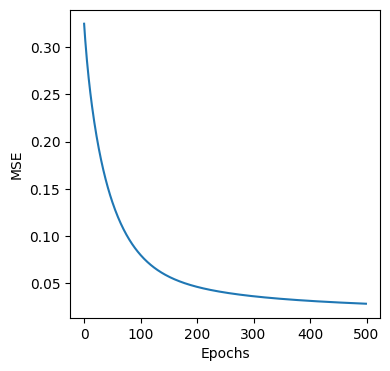

In [18]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(4,4))
plt.plot(all_losses)
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.show()

(360, 2)


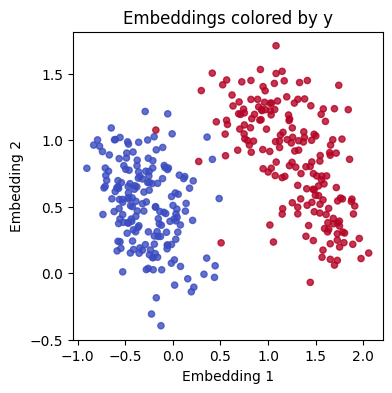

In [19]:
embeddings = X @ W1
print(embeddings.shape)

plt.figure(figsize=(4,4))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c=y.ravel(), cmap='coolwarm', s=20, alpha=0.8)
plt.xlabel('Embedding 1')
plt.ylabel('Embedding 2')
plt.title('Embeddings colored by y')
plt.show()

In [20]:
W2

array([[0.50835318],
       [0.35377862]])